In [1]:
import pandas as pd
cleaned = pd.read_parquet("data/processed/2025_Bahrain_clean.parquet")

# does lap 1 look like an outlier?
cleaned.groupby("LapNumber")["LapTimeCorrected"].mean().head(5)

LapNumber
1.0    101.961750
2.0     99.097650
3.0     98.998350
4.0     99.013900
5.0     99.454211
Name: LapTimeCorrected, dtype: float64

<Axes: xlabel='TyreLife', ylabel='LapTimeCorrected'>

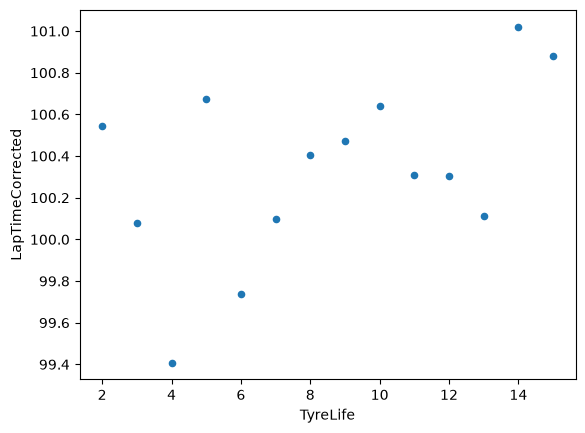

In [2]:
import pandas as pd

cleaned = pd.read_parquet("data/processed/2025_Bahrain_clean.parquet")

# does ONE driver's ONE stint show the expected positive trend?
one_stint = cleaned[(cleaned["Driver"] == "ALO") & (cleaned["Stint"] == 1)]
one_stint[["TyreLife", "LapTimeCorrected"]].plot(x="TyreLife", y="LapTimeCorrected", kind="scatter")

In [3]:
import numpy as np

def stint_slope(group):
    if len(group) < 4:
        return np.nan
    return np.polyfit(group["TyreLife"], group["LapTimeCorrected"], 1)[0]

slopes = cleaned.groupby(["Driver", "Stint"]).apply(stint_slope)
print(slopes.describe())
print((slopes > 0).mean())  # fraction of stints with positive degradation

count    59.000000
mean     -0.097244
std       0.374022
min      -2.465317
25%      -0.285835
50%       0.040156
75%       0.104457
max       0.180343
dtype: float64
0.5737704918032787


C:\Users\asus\AppData\Local\Temp\ipykernel_24312\3172544997.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slopes = cleaned.groupby(["Driver", "Stint"]).apply(stint_slope)


In [4]:
import pandas as pd
from models.degradation import stint_slopes_for_compound

cleaned = pd.read_parquet("data/processed/2025_Bahrain_clean.parquet")
print(stint_slopes_for_compound(cleaned, "HARD").to_string())

   Driver  Stint  intercept_s  slope_s_per_lap  n_laps  r_squared
11    SAI    3.0   121.536772        -2.465317       9   0.292379
9     LEC    3.0   106.202747        -0.411706      23   0.076444
7     HAM    3.0   106.237893        -0.397421      23   0.080589
5     GAS    3.0   107.558712        -0.363240      26   0.087783
4     DOO    3.0   107.957383        -0.356087      26   0.095200
6     HAD    3.0   107.563747        -0.351561      26   0.125431
1     ALO    3.0   105.867737        -0.325720      23   0.112702
10    OCO    3.0   106.692828        -0.295677      27   0.070132
12    STR    3.0   103.567093        -0.185078      23   0.090472
3     BOR    2.0    99.036422         0.106211      17   0.778824
8     LAW    2.0    98.763850         0.115450      16   0.525598
2     BEA    2.0    98.153310         0.135040      16   0.779996
13    VER    2.0    98.011936         0.152218      14   0.484708
0     ALB    2.0    97.757303         0.157191      14   0.757611


In [2]:
import pandas as pd
cleaned = pd.read_parquet("data/processed/2025_Bahrain_clean.parquet")
hard = cleaned[cleaned["Compound"] == "HARD"]
stint_starts = hard.groupby(["Driver","Stint"])["LapNumber"].min()
print(stint_starts.sort_values())

Driver  Stint
VER     2.0      13.0
BOR     2.0      16.0
LAW     2.0      17.0
BEA     2.0      17.0
ALB     2.0      19.0
OCO     3.0      30.0
HAD     3.0      31.0
DOO     3.0      31.0
GAS     3.0      31.0
ALO     3.0      35.0
HAM     3.0      35.0
LEC     3.0      35.0
SAI     3.0      35.0
STR     3.0      35.0
Name: LapNumber, dtype: float64


In [ ]:
import fastf1
session = fastf1.get_session(2025, "Bahrain", "R")
session.load(telemetry=False)

for driver in ["PIA", "RUS", "NOR"]:
    laps = session.laps.pick_drivers(driver)
    stints = laps.groupby("Stint").agg(
        Compound=("Compound", "first"),
        StartLap=("LapNumber", "min"),
        EndLap=("LapNumber", "max"),
    )
    stints["Length"] = stints["EndLap"] - stints["StartLap"] + 1
    print(f"\n{driver}")
    print(stints)

req         WARNING 	DEFAULT CACHE ENABLED! (24.0 KB) C:\Users\asus\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track 


PIA
      Compound  StartLap  EndLap  Length
Stint                                   
1.0       SOFT       1.0    14.0    14.0
2.0     MEDIUM      15.0    32.0    18.0
3.0     MEDIUM      33.0    57.0    25.0

RUS
      Compound  StartLap  EndLap  Length
Stint                                   
1.0       SOFT       1.0    13.0    13.0
2.0     MEDIUM      14.0    32.0    19.0
3.0       SOFT      33.0    57.0    25.0

NOR
      Compound  StartLap  EndLap  Length
Stint                                   
1.0       SOFT       1.0    10.0    10.0
2.0     MEDIUM      11.0    32.0    22.0
3.0     MEDIUM      33.0    57.0    25.0
